# Chunk-Level XGBoost — RT (Deployment-Safe Features)

Trains XGBoost on deployment-safe features only and evaluates at chunk level.

**Features excluded (not available at prediction time):**  
`Travel_Distance`, `same_aisle`, `same_lockey`, `same_location`, `same_level`, `diff_level`, `time_of_day`, `day_of_week`, `hour`

In [26]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import importlib
import feature_engineer
importlib.reload(feature_engineer)
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH         = Path("../data/processed")
WAREHOUSE    = "RT"
MAX_TIME     = 300
BLOCK_SIZE   = 50
RANDOM_STATE = 2026

# Features not available at prediction time — excluded from XGBoost
NOT_AVAILABLE = [
    "Travel_Distance",
    "same_aisle", "same_lockey", "same_location", "same_level", "diff_level",
    "time_of_day", "day_of_week", "hour",
]


In [27]:
def resolve_data_path(warehouse):
    return PATH / f"{warehouse.lower()}_detailed.parquet"


_df_raw = pd.read_parquet(resolve_data_path(WAREHOUSE))
_df_raw["WorkCode"] = _df_raw["WorkCode"].astype(str).apply(
    lambda x: x.split(".")[0] if isinstance(x, str) else x
)
WORKCODES = sorted(_df_raw["WorkCode"].dropna().unique().tolist())
print(f"WorkCodes found: {WORKCODES}")
del _df_raw



def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=resolve_data_path(warehouse),
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode,
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    features = [f for f in features_all if f not in NOT_AVAILABLE]
    cat_cols = [c for c in cat_cols_all if c not in NOT_AVAILABLE]
    return d, features, cat_cols


def split_by_days(df, test_ratio=0.15):
    all_days    = sorted(df["date"].dropna().unique())
    n_test_days = max(1, int(round(len(all_days) * test_ratio)))
    test_days   = all_days[-n_test_days:]
    train_df    = df[df["date"] < test_days[0]].copy()
    test_df     = df[df["date"].isin(test_days)].copy()
    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def eval_predictions(y_true, pred):
    return {
        "r2":   r2_score(y_true, pred),
        "mae":  mean_absolute_error(y_true, pred),
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
    }


def make_test_blocks(test_df, block_size=BLOCK_SIZE):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks, block_rows = [], []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.sort_values("Timestamp").reset_index().rename(columns={"index": "orig_index"}).copy()
        for start in range(0, len(g), block_size):
            chunk = g.iloc[start:start + block_size].copy()
            if len(chunk) < block_size:
                continue
            if chunk["WorkCode"].nunique() != 1:
                continue
            if (chunk["Time_Delta_sec"] > MAX_TIME).any():
                continue
            block_id = f"{uid}_{day}_{start // block_size}"
            chunk["BlockID"] = block_id
            block_rows.append(chunk)
            blocks.append({
                "BlockID":     block_id,
                "UserID":      uid,
                "date":        day,
                "WorkCode":    chunk["WorkCode"].iloc[0],
                "n_tasks":     len(chunk),
                "actual_time": chunk["Time_Delta_sec"].sum(),
                "start_ts":    chunk["Timestamp"].min(),
                "end_ts":      chunk["Timestamp"].max(),
            })
    block_df     = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df


WorkCodes found: ['1', '11', '13', '14', '15', '2', '3', '4', '5', '6', 'nan']


In [28]:
all_task_results  = []
all_block_results = []
all_block_detail  = []

xgb_params = dict(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:tweedie",
    tweedie_variance_power=1.3,
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc}")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)
    print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
    print(f"Features: {features}")

    y_train = train_df["Time_Delta_sec"].astype(float)
    y_test  = test_df["Time_Delta_sec"].astype(float)

    X_train, X_test = make_X(train_df, test_df, features, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    all_task_results.append({
        "Warehouse":    WAREHOUSE,
        "WorkCode":     wc,
        "n_train_rows": len(train_df),
        "n_test_rows":  len(test_df),
        "runtime_sec":  runtime,
        **eval_predictions(y_test, preds)
    })

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail.append(block_pred)

task_results_df  = pd.DataFrame(all_task_results)
block_results_df = pd.DataFrame(all_block_results)
block_detail_df  = pd.concat(all_block_detail, ignore_index=True) if all_block_detail else pd.DataFrame()
print("\nDone.")



WorkCode 1
Train: 5578 rows | Test: 992 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
  Blocks: 17 | MAE: 326.9s | MAE/task: 6.538s | R²: -0.4738

WorkCode 11
Train: 5850 rows | Test: 913 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
  Blocks: 11 | MAE: 1975.9s | MAE/task: 39.519s | R²: -10.5331

WorkCode 13
Train: 63 rows | Test: 12 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
No valid blocks for WC 13

WorkCode 14
Train: 675 rows | Test: 147 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
No valid blocks for WC 14

WorkCode 15
Train: 423 rows | Test: 100 rows
Features: ['Weight', 'Cube', 'Quantity', 'Aisle_group', 'Level_group', 'UOM_group', 'top_100_product']
No valid blocks for WC 15

WorkCode 2
Train: 7899 rows | Test: 1374 rows
Features

In [29]:
block_results_clean = block_results_df.copy()
for c in ["r2", "mae", "rmse"]:
    if c in block_results_clean.columns:
        block_results_clean[c] = block_results_clean[c].round(3)
block_results_clean["mae_per_task"] = (block_results_clean["mae"] / BLOCK_SIZE).round(3)
block_results_clean = block_results_clean.drop(columns=["rmse", "Warehouse"], errors="ignore")

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(block_results_clean.sort_values(["WorkCode", "mae_per_task"]).reset_index(drop=True))


Warehouse: RT | Block size: 50 tasks


,WorkCode,n_blocks,r2,mae,mae_per_task
0,1,17,-0.474,326.920,6.538
1,11,11,-10.533,1975.943,39.519
2,2,25,0.312,298.165,5.963
3,3,14,-0.655,297.342,5.947
4,4,25,0.353,301.944,6.039
5,5,41,-0.013,242.284,4.846
6,6,55,-0.220,682.178,13.644


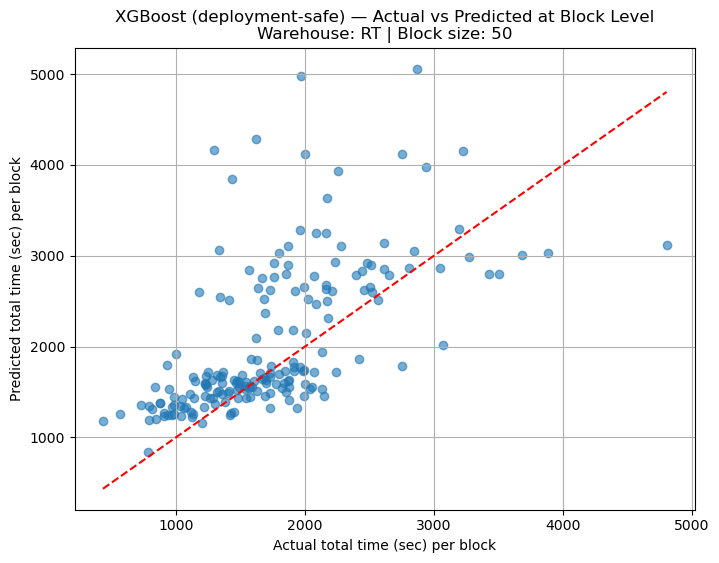

In [30]:
plot_df = block_detail_df[block_detail_df["Warehouse"] == WAREHOUSE].copy()
plot_df = plot_df[plot_df["pred"].notna()].copy()

plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual_time"], plot_df["pred"], alpha=0.6)
plt.plot(
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    [plot_df["actual_time"].min(), plot_df["actual_time"].max()],
    color="red", linestyle="--"
)
plt.xlabel("Actual total time (sec) per block")
plt.ylabel("Predicted total time (sec) per block")
plt.title(f"XGBoost (deployment-safe) — Actual vs Predicted at Block Level\n"
          f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE}")
plt.grid(True)
plt.show()


In [31]:
# ── Worker Random Intercept (Mixed Effects) ────────────────────────────────
# Fits Time_Delta_sec ~ 1 + (1|UserID) on training data only.
# Extracts per-worker effect b_j and adds it as a feature to XGBoost.
# Unseen workers at test time get effect = 0 (grand mean fallback).

def estimate_worker_effects(train_df):
    """
    Fits a random intercept model on training data.
    Returns a DataFrame with columns [UserID, worker_effect].
    worker_effect is the b_j estimate: positive = slower than average.
    """
    df_re = train_df[["UserID", "Time_Delta_sec"]].dropna().copy()
    if df_re["UserID"].nunique() < 2:
        print("  [Warning] Not enough workers — skipping worker effects")
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_effect": 0.0})

    result = smf.mixedlm(
        "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
    ).fit(reml=True, disp=False)

    icc = result.cov_re.values[0][0] / (result.cov_re.values[0][0] + result.scale)
    print(f"  Grand mean: {result.fe_params['Intercept']:.1f}s | "
          f"Worker SD: {np.sqrt(result.cov_re.values[0][0]):.1f}s | ICC: {icc:.3f}")

    return pd.DataFrame({
        "UserID":        list(result.random_effects.keys()),
        "worker_effect": [float(v.iloc[0]) for v in result.random_effects.values()]
    })


all_block_results_w = []
all_block_detail_w  = []

for wc in WORKCODES:
    print(f"\n{'='*50}")
    print(f"WorkCode {wc} — + Worker Effect")
    print(f"{'='*50}")

    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, test_df, test_days = split_by_days(df_wc)

    # Estimate worker effects on training data only — no leakage
    print("  Fitting mixed model...")
    worker_effects = estimate_worker_effects(train_df)

    # Join worker_effect — unseen workers get 0 (grand mean fallback)
    train_df = train_df.merge(worker_effects, on="UserID", how="left")
    test_df  = test_df.merge(worker_effects,  on="UserID", how="left")
    train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
    test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

    # Reset index — critical for block index alignment
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    y_train  = train_df["Time_Delta_sec"].astype(float)
    y_test   = test_df["Time_Delta_sec"].astype(float)

    # Add worker_effect to feature set
    feats_w = features + ["worker_effect"]
    X_train, X_test = make_X(train_df, test_df, feats_w, cat_cols)

    t0    = time.perf_counter()
    model = XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    runtime = time.perf_counter() - t0

    # Block-level evaluation
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)
    if len(block_df) == 0:
        print(f"  No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred"] = preds
    block_rows_df = block_rows_df.merge(temp[["orig_index", "pred"]], on="orig_index", how="left")

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred=("pred", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    metrics = eval_predictions(block_pred["actual_time"], block_pred["pred"])
    print(f"  Blocks: {len(block_pred)} | MAE: {metrics['mae']:.1f}s | "
          f"MAE/task: {metrics['mae']/BLOCK_SIZE:.3f}s | R²: {metrics['r2']:.4f}")

    all_block_results_w.append({
        "Warehouse": WAREHOUSE,
        "WorkCode":  wc,
        "n_blocks":  len(block_pred),
        **metrics
    })
    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail_w.append(block_pred)

block_results_w_df = pd.DataFrame(all_block_results_w)
block_detail_w_df  = pd.concat(all_block_detail_w, ignore_index=True) if all_block_detail_w else pd.DataFrame()
print("\nDone.")



WorkCode 1 — + Worker Effect
  Fitting mixed model...
  Grand mean: 26.2s | Worker SD: 4.4s | ICC: 0.029
  Blocks: 17 | MAE: 267.3s | MAE/task: 5.346s | R²: 0.0745

WorkCode 11 — + Worker Effect
  Fitting mixed model...
  Grand mean: 61.5s | Worker SD: 25.4s | ICC: 0.185
  Blocks: 11 | MAE: 493.7s | MAE/task: 9.874s | R²: 0.0019

WorkCode 13 — + Worker Effect
  Fitting mixed model...
  Grand mean: 118.3s | Worker SD: 26.1s | ICC: 0.105
  No valid blocks for WC 13

WorkCode 14 — + Worker Effect
  Fitting mixed model...
  Grand mean: 23.3s | Worker SD: 27.9s | ICC: 0.455
  No valid blocks for WC 14

WorkCode 15 — + Worker Effect
  Fitting mixed model...
  Grand mean: 81.4s | Worker SD: 18.9s | ICC: 0.085
  No valid blocks for WC 15

WorkCode 2 — + Worker Effect
  Fitting mixed model...
  Grand mean: 35.8s | Worker SD: 9.0s | ICC: 0.091
  Blocks: 25 | MAE: 124.9s | MAE/task: 2.498s | R²: 0.8636

WorkCode 3 — + Worker Effect
  Fitting mixed model...
  Grand mean: 35.3s | Worker SD: 6.2s |

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


  No valid blocks for WC nan

Done.


In [32]:
# extract all worker effects
worker_effects_all = []
for wc in WORKCODES:
    df_wc, features, cat_cols = load_engineered_data(WAREHOUSE, wc, MAX_TIME)
    train_df, _, _ = split_by_days(df_wc)
    worker_effects = estimate_worker_effects(train_df)
    worker_effects["WorkCode"] = wc
    worker_effects_all.append(worker_effects)
worker_effects_df = pd.concat(worker_effects_all, ignore_index=True)

  Grand mean: 26.2s | Worker SD: 4.4s | ICC: 0.029
  Grand mean: 61.5s | Worker SD: 25.4s | ICC: 0.185
  Grand mean: 118.3s | Worker SD: 26.1s | ICC: 0.105
  Grand mean: 23.3s | Worker SD: 27.9s | ICC: 0.455
  Grand mean: 81.4s | Worker SD: 18.9s | ICC: 0.085
  Grand mean: 35.8s | Worker SD: 9.0s | ICC: 0.091
  Grand mean: 35.3s | Worker SD: 6.2s | ICC: 0.033
  Grand mean: 34.9s | Worker SD: 4.4s | ICC: 0.017
  Grand mean: 35.9s | Worker SD: 10.0s | ICC: 0.104
  Grand mean: 49.6s | Worker SD: 18.0s | ICC: 0.154
  Grand mean: 114.3s | Worker SD: 0.4s | ICC: 0.000


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


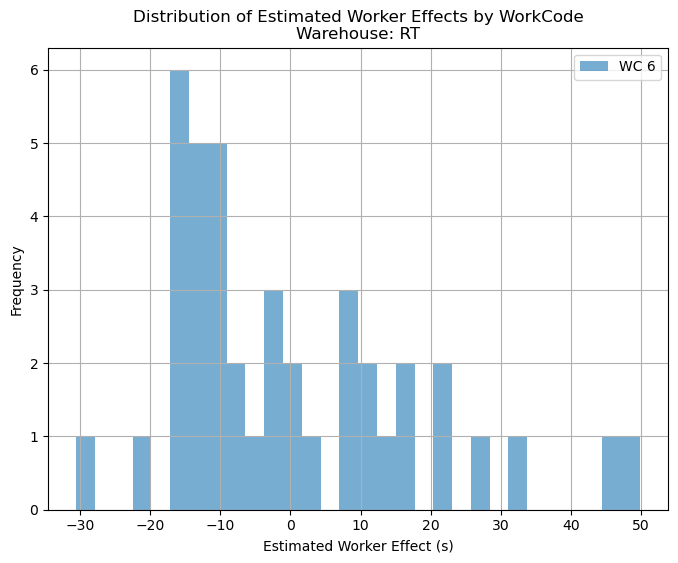

Worker Effect Percentiles for WC 6:
  10th percentile: -15.4s
  25th percentile: -12.3s
  50th percentile: -5.4s
  75th percentile: 10.8s
  90th percentile: 22.7s
  Mean: -0.0s


In [34]:
plt.figure(figsize=(8, 6))
subset = worker_effects_df[worker_effects_df["WorkCode"] == "6"]
plt.hist(subset["worker_effect"], bins=30, alpha=0.6, label=f"WC 6")
plt.xlabel("Estimated Worker Effect (s)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Estimated Worker Effects by WorkCode\nWarehouse: {WAREHOUSE}")
plt.legend()
plt.grid(True)
plt.show()

# compute 10, 25, 50, mean, 75, 90 percentiles of worker effects for WC 6
percentiles = [10, 25, 50, 75, 90]
percentile_values = np.percentile(subset["worker_effect"], percentiles)
print(f"Worker Effect Percentiles for WC 6:")
for p, val in zip(percentiles, percentile_values):
    print(f"  {p}th percentile: {val:.1f}s")
print(f"  Mean: {subset['worker_effect'].mean():.1f}s")


In [35]:
# Compare baseline vs + worker at chunk level
rows = []
for wc in WORKCODES:
    base = block_results_df[block_results_df["WorkCode"] == wc]
    enh  = block_results_w_df[block_results_w_df["WorkCode"] == wc]
    if base.empty or enh.empty:
        continue
    mae_base = base["mae"].values[0]
    mae_enh  = enh["mae"].values[0]
    rows.append({
        "WorkCode":              wc,
        "MAE/task baseline (s)": round(mae_base / BLOCK_SIZE, 3),
        "MAE/task + worker (s)": round(mae_enh  / BLOCK_SIZE, 3),
        "Improvement (s)":       round((mae_base - mae_enh) / BLOCK_SIZE, 3),
        "Improvement (%)": round((mae_base - mae_enh) / mae_base * 100, 2),
        "R² baseline":           round(base["r2"].values[0], 4),
        "R² + worker":           round(enh["r2"].values[0],  4),
    })

print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")
display(pd.DataFrame(rows))


Warehouse: RT | Block size: 50 tasks


,WorkCode,MAE/task baseline (s),MAE/task + worker (s),Improvement (s),Improvement (%),R² baseline,R² + worker
0,1,6.538,5.346,1.192,18.23,-0.4738,0.0745
1,11,39.519,9.874,29.645,75.01,-10.5331,0.0019
2,2,5.963,2.498,3.465,58.11,0.3120,0.8636
3,3,5.947,4.089,1.858,31.24,-0.6545,0.1413
4,4,6.039,4.369,1.670,27.65,0.3528,0.5568
5,5,4.846,3.495,1.351,27.88,-0.0133,0.5589
6,6,13.644,11.769,1.875,13.74,-0.2196,0.0249


# WC11 — dramatic improvement but highly unstable baseline
MAE/task drops from 39.519s to 9.874s, a 75% improvement, and R² recovers from -10.53 to near zero (0.002). The baseline model was completely failing without worker effects — R² of -10.53 is extreme, suggesting either very few test blocks, highly variable pick times in this WorkCode, or both. Worker effects rescue the model from catastrophic failure but the final R² of 0.002 means prediction quality is still very poor. Treat as low confidence and flag for investigation.

# WC2 — exceptional result
Same as before. MAE/task drops from 5.963s to 2.498s, a 58% improvement, R² from 0.31 to 0.86. Strongest reliable result across all three warehouses.

# WC5 — strong positive result
MAE/task drops from 4.846s to 3.495s, a 28% improvement, R² from near zero to 0.56. Baseline was essentially no better than predicting the mean and worker effects rescued it.

# WC3 and WC4 — moderate improvement
WC3 improves 31% and WC4 improves 28%. Both have low ICC so the improvements are notable given weak worker signal.

# WC1 — modest improvement
18% improvement, ICC of 0.029, thin block count. Low confidence.

# WC6 — weak improvement, concerning baseline
Baseline MAE/task of 13.644s remains the highest of all standard WorkCodes. 14% improvement but R² stays near zero. Task features are insufficient for WC6 regardless of worker effects. Needs separate investigation.

# Overall conclusion
RT now shows seven WorkCodes including the newly discovered WC11. Worker effects help across all WorkCodes including the extreme case of WC11, though the results for WC11 and WC1 are too thin to be reliable. The strongest and most trustworthy improvements are WC2 (58%) and WC5 (28%). The pattern holds — worker effects help most where ICC is meaningful and data is sufficient.

In [36]:
import pickle

results = {
    "WAREHOUSE":          WAREHOUSE,
    "WORKCODES":          WORKCODES,
    "BLOCK_SIZE":         BLOCK_SIZE,

    # Baseline XGBoost results
    "block_results_df":   block_results_df,
    "block_detail_df":    block_detail_df,

    # + Worker effects results  
    "block_results_w_df": block_results_w_df,
    "block_detail_w_df":  block_detail_w_df,

    # Worker effects table
    "worker_effects_df":  worker_effects_df,
}

with open(f"results_{WAREHOUSE.lower()}.pkl", "wb") as f:
    pickle.dump(results, f)

print(f"Saved results_{WAREHOUSE.lower()}.pkl")

Saved results_rt.pkl
